# RS1 — BPR Matrix Factorization
**Conventional Recommender System using Bayesian Personalised Ranking.**

> ⚠️ Run `Data_Preparation.ipynb` first before executing this notebook.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/Recommendation System'
PROC = f'{BASE}/data/processed'
MODELS_DIR = f'{BASE}/models'
OUT_DIR = f'{BASE}/outputs'
print('✅ Drive mounted.')

Mounted at /content/drive
✅ Drive mounted.


## Install & Import Libraries

In [2]:
!pip install -q torch pandas numpy scikit-learn matplotlib tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import pickle, json, time
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')

✅ Using device: cpu


## Laod Preprocessed Data

In [3]:
train_df  = pd.read_csv(f'{PROC}/train.csv')
test_df   = pd.read_csv(f'{PROC}/test.csv')
movies_df = pd.read_csv(f'{PROC}/movies.csv')

with open(f'{PROC}/dataset_info.json') as f:
    info = json.load(f)

with open(f'{PROC}/train_user_items.pkl', 'rb') as f:
    train_user_items = pickle.load(f)

with open(f'{PROC}/item_popularity.pkl', 'rb') as f:
    item_popularity = pickle.load(f)

NUM_USERS = int(train_df['user_idx'].max()) + 1
NUM_ITEMS = int(train_df['item_idx'].max()) + 1

idx_to_title = dict(zip(movies_df['item_idx'], movies_df['title']))

print(f'Users: {NUM_USERS:,}  |  Items: {NUM_ITEMS:,}')
print(f'Train: {len(train_df):,}  |  Test: {len(test_df):,}')
print('✅ Data loaded.')

Users: 6,018  |  Items: 3,390
Train: 143,978  |  Test: 5,934
✅ Data loaded.


## BPR Dataset (Negative Sampling)

In [4]:
from torch.utils.data import Dataset, DataLoader

class BPRDataset(Dataset):
    """
    For each (user, positive_item) pair, sample one negative item
    (an item the user has NOT interacted with in training).
    Returns triples: (user, pos_item, neg_item)
    """
    def __init__(self, train_df, train_user_items, num_items):
        self.interactions = list(zip(train_df['user_idx'], train_df['item_idx']))
        self.train_user_items = train_user_items
        self.num_items = num_items
        self.all_items = set(range(num_items))

    def __len__(self):
        return len(self.interactions)

    def __getitem__(self, idx):
        user, pos_item = self.interactions[idx]
        # Sample a negative item not in user's history
        neg_item = np.random.randint(0, self.num_items)
        while neg_item in self.train_user_items.get(user, set()):
            neg_item = np.random.randint(0, self.num_items)
        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(pos_item, dtype=torch.long),
            torch.tensor(neg_item, dtype=torch.long)
        )

dataset = BPRDataset(train_df, train_user_items, NUM_ITEMS)
loader  = DataLoader(dataset, batch_size=2048, shuffle=True, num_workers=2)
print(f'✅ BPR Dataset ready. Batches per epoch: {len(loader):,}')

✅ BPR Dataset ready. Batches per epoch: 71


## BPR-MF Model Definition

In [5]:
class BPRMF(nn.Module):

    def __init__(self, num_users, num_items, embedding_dim=64, reg_lambda=1e-4):
        super(BPRMF, self).__init__()
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)
        self.reg_lambda = reg_lambda

        # Xavier uniform initialisation for stable training
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

    def forward(self, users, pos_items, neg_items):
        u  = self.user_emb(users)      # (batch, dim)
        pi = self.item_emb(pos_items)
        ni = self.item_emb(neg_items)

        pos_score = (u * pi).sum(dim=1)  # dot product
        neg_score = (u * ni).sum(dim=1)

        # BPR pairwise loss
        bpr_loss = -torch.log(torch.sigmoid(pos_score - neg_score) + 1e-10).mean()

        # L2 regularisation
        reg_loss = self.reg_lambda * (
            u.norm(2).pow(2) + pi.norm(2).pow(2) + ni.norm(2).pow(2)
        ) / users.shape[0]

        return bpr_loss + reg_loss

    def get_scores(self, user_idx):
        """Return scores for all items for a single user (used at inference)."""
        u = self.user_emb.weight[user_idx]           # (dim,)
        all_items = self.item_emb.weight               # (num_items, dim)
        scores = torch.matmul(all_items, u)            # (num_items,)
        return scores.detach().cpu().numpy()

# Instantiate
EMBEDDING_DIM = 64
model_rs1 = BPRMF(NUM_USERS, NUM_ITEMS, embedding_dim=EMBEDDING_DIM).to(DEVICE)
print(model_rs1)
total_params = sum(p.numel() for p in model_rs1.parameters())
print(f'\nTotal parameters: {total_params:,}')

BPRMF(
  (user_emb): Embedding(6018, 64)
  (item_emb): Embedding(3390, 64)
)

Total parameters: 602,112


## Training Loop

In [6]:
EPOCHS    = 30
LR        = 0.001
optimizer = optim.Adam(model_rs1.parameters(), lr=LR)

train_losses = []
start_time = time.time()

print(f'Training RS1 (BPR-MF) for {EPOCHS} epochs...')
print(f'Embedding dim: {EMBEDDING_DIM}  |  Batch size: 2048  |  LR: {LR}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    model_rs1.train()
    epoch_loss = 0.0

    for batch_users, batch_pos, batch_neg in loader:
        batch_users = batch_users.to(DEVICE)
        batch_pos   = batch_pos.to(DEVICE)
        batch_neg   = batch_neg.to(DEVICE)

        optimizer.zero_grad()
        loss = model_rs1(batch_users, batch_pos, batch_neg)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    train_losses.append(avg_loss)

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - start_time
        print(f'Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.5f} | Time: {elapsed:.1f}s')

print('-' * 55)
print(f'✅ Training complete in {(time.time()-start_time)/60:.1f} minutes.')

# Save model checkpoint
torch.save(model_rs1.state_dict(), f'{MODELS_DIR}/rs1_bprmf.pth')
print('✅ Model saved.')

Training RS1 (BPR-MF) for 30 epochs...
Embedding dim: 64  |  Batch size: 2048  |  LR: 0.001
-------------------------------------------------------
Epoch   1/30 | Loss: 0.69313 | Time: 6.7s
Epoch   5/30 | Loss: 0.52368 | Time: 27.0s
Epoch  10/30 | Loss: 0.38393 | Time: 53.6s
Epoch  15/30 | Loss: 0.33694 | Time: 78.0s
Epoch  20/30 | Loss: 0.29548 | Time: 105.7s
Epoch  25/30 | Loss: 0.25727 | Time: 132.1s
Epoch  30/30 | Loss: 0.22645 | Time: 157.7s
-------------------------------------------------------
✅ Training complete in 2.6 minutes.
✅ Model saved.


##  Plot Training Loss

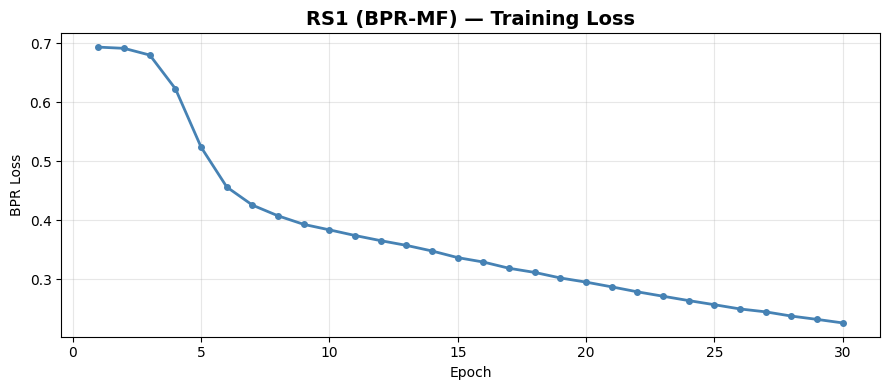

✅ Training loss plot saved.


In [7]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', markersize=4, color='steelblue', linewidth=2)
plt.title('RS1 (BPR-MF) — Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rs1_training_loss.png', dpi=150)
plt.show()
print('✅ Training loss plot saved.')

## Recommendation Function

In [8]:
def recommend_rs1(model, user_idx, train_user_items, k=10):
    """
    Generate Top-K recommendations for a given user.

    Steps:
    1. Get scores for ALL items using dot product of user and item embeddings.
    2. Mask out items the user already interacted with in training.
    3. Return the Top-K highest-scoring unseen items.
    """
    model.eval()
    with torch.no_grad():
        scores = model.get_scores(user_idx)  # (num_items,)

    seen = train_user_items.get(user_idx, set())
    for item in seen:
        scores[item] = -np.inf

    # Get Top-K
    top_k = np.argsort(scores)[::-1][:k]
    return top_k.tolist()

# Quick test
sample_user = list(train_user_items.keys())[0]
recs = recommend_rs1(model_rs1, sample_user, train_user_items, k=10)
print(f'Top-10 recommendations for user {sample_user}:')
for rank, item_idx in enumerate(recs, 1):
    title = idx_to_title.get(item_idx, f'Movie_{item_idx}')
    print(f'  {rank:2d}. {title}')

Top-10 recommendations for user 0:
   1. Star Wars: Episode IV - A New Hope (1977)
   2. Jurassic Park (1993)
   3. Alien (1979)
   4. Terminator, The (1984)
   5. Men in Black (1997)
   6. Silence of the Lambs, The (1991)
   7. Shakespeare in Love (1998)
   8. Star Wars: Episode I - The Phantom Menace (1999)
   9. Ghostbusters (1984)
  10. Jaws (1975)


## Evaluation Metrics (NDCG@K and Novelty@K)

In [9]:

# METRIC 1: NDCG@K (Normalised Discounted Cumulative Gain)
# Measures ranking quality. A hit at position 1 scores higher
# than a hit at position K. Uses log2 discounting.
# Formula: NDCG@K = 1 / log2(rank + 1)  if test_item in top-K, else 0


def ndcg_at_k(recommended_list, test_item, k=10):
    """NDCG@K for a single user. Returns value in [0,1]."""
    if test_item in recommended_list[:k]:
        rank = recommended_list[:k].index(test_item) + 1  # 1-indexed
        return 1.0 / np.log2(rank + 1)
    return 0.0


# METRIC 2: Novelty@K
# Measures how 'surprising' or 'non-obvious' the recommendations are.
# Popular items have low novelty; rare items have high novelty.
# Formula: Novelty@K = mean( -log2(pop(i)) ) for i in Top-K


def novelty_at_k(recommended_list, item_popularity, k=10):
    """Novelty@K for a single user. Higher = more novel."""
    top_k = recommended_list[:k]
    scores = [-np.log2(item_popularity.get(i, 1e-10) + 1e-10) for i in top_k]
    return np.mean(scores)


print('✅ Metric functions defined.')
print('  Metric 1: NDCG@10  — Ranking accuracy')
print('  Metric 2: Novelty@10 — Beyond-accuracy (surprisingness)')

✅ Metric functions defined.
  Metric 1: NDCG@10  — Ranking accuracy
  Metric 2: Novelty@10 — Beyond-accuracy (surprisingness)


## Run Full Evaluation on RS1

In [10]:
K = 10
ndcg_scores    = []
novelty_scores = []

model_rs1.eval()
test_users = test_df['user_idx'].tolist()
test_items = test_df['item_idx'].tolist()

print(f'Evaluating RS1 on {len(test_users):,} users...')

for user_idx, test_item in tqdm(zip(test_users, test_items), total=len(test_users)):
    recs = recommend_rs1(model_rs1, user_idx, train_user_items, k=K)
    ndcg_scores.append(ndcg_at_k(recs, test_item, k=K))
    novelty_scores.append(novelty_at_k(recs, item_popularity, k=K))

rs1_ndcg    = np.mean(ndcg_scores)
rs1_novelty = np.mean(novelty_scores)

print('\n' + '='*40)
print('RS1 (BPR-MF) Evaluation Results')
print('='*40)
print(f'  NDCG@{K}:    {rs1_ndcg:.5f}')
print(f'  Novelty@{K}: {rs1_novelty:.4f}')
print('='*40)

# Save results
import json
rs1_results = {
    'model': 'RS1_BPR_MF',
    f'ndcg@{K}': round(rs1_ndcg, 6),
    f'novelty@{K}': round(rs1_novelty, 6),
    'num_eval_users': len(test_users)
}
with open(f'{OUT_DIR}/rs1_results.json', 'w') as f:
    json.dump(rs1_results, f, indent=2)
print('\n✅ Results saved.')

Evaluating RS1 on 5,934 users...


100%|██████████| 5934/5934 [00:02<00:00, 2753.23it/s]


RS1 (BPR-MF) Evaluation Results
  NDCG@10:    0.01491
  Novelty@10: 4.4236

✅ Results saved.


## Display Top-10 Recommendations for 6 Users

In [11]:
# Pick 6 representative users
demo_users = list(train_user_items.keys())[:6]

print('RS1 (BPR-MF) — Top-10 Recommendations for 6 Users')
print('='*65)

rs1_demo_recs = {}

for user_idx in demo_users:
    recs = recommend_rs1(model_rs1, user_idx, train_user_items, k=10)
    rs1_demo_recs[user_idx] = recs
    print(f'\nUser {user_idx} | Seen {len(train_user_items[user_idx])} movies in training')
    print('-'*50)
    for rank, item_idx in enumerate(recs, 1):
        title = idx_to_title.get(item_idx, f'Movie_{item_idx}')
        print(f'  {rank:2d}. [{item_idx:4d}] {title}')

# Save demo recs
with open(f'{OUT_DIR}/rs1_demo_recs.json', 'w') as f:
    json.dump({str(k): v for k,v in rs1_demo_recs.items()}, f, indent=2)
print('\n✅ Demo recommendations saved.')

RS1 (BPR-MF) — Top-10 Recommendations for 6 Users

User 0 | Seen 47 movies in training
--------------------------------------------------
   1. [  27] Star Wars: Episode IV - A New Hope (1977)
   2. [  75] Jurassic Park (1993)
   3. [  11] Alien (1979)
   4. [ 574] Terminator, The (1984)
   5. [  15] Men in Black (1997)
   6. [ 293] Silence of the Lambs, The (1991)
   7. [ 540] Shakespeare in Love (1998)
   8. [ 109] Star Wars: Episode I - The Phantom Menace (1999)
   9. [  86] Ghostbusters (1984)
  10. [ 169] Jaws (1975)

User 1 | Seen 7 movies in training
--------------------------------------------------
   1. [ 511] Fargo (1996)
   2. [ 465] American Beauty (1999)
   3. [ 339] Schindler's List (1993)
   4. [ 138] Pulp Fiction (1994)
   5. [ 160] One Flew Over the Cuckoo's Nest (1975)
   6. [  88] Back to the Future (1985)
   7. [ 121] Star Wars: Episode V - The Empire Strikes Back (1980)
   8. [ 989] L.A. Confidential (1997)
   9. [ 156] Star Wars: Episode VI - Return of the Jedi (

## Score Distribution Plot

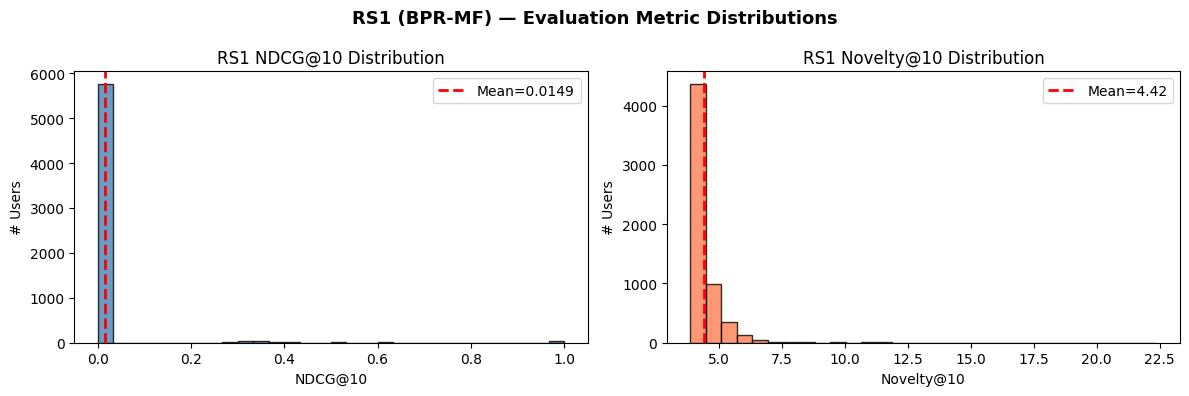

✅ Plot saved.


In [12]:
# Visualise NDCG distribution across all users
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(ndcg_scores, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(rs1_ndcg, color='red', linestyle='--', linewidth=2, label=f'Mean={rs1_ndcg:.4f}')
axes[0].set_title(f'RS1 NDCG@{K} Distribution')
axes[0].set_xlabel('NDCG@10')
axes[0].set_ylabel('# Users')
axes[0].legend()

axes[1].hist(novelty_scores, bins=30, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(rs1_novelty, color='red', linestyle='--', linewidth=2, label=f'Mean={rs1_novelty:.2f}')
axes[1].set_title(f'RS1 Novelty@{K} Distribution')
axes[1].set_xlabel('Novelty@10')
axes[1].set_ylabel('# Users')
axes[1].legend()

plt.suptitle('RS1 (BPR-MF) — Evaluation Metric Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/rs1_metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved.')